# **Splitting and Merging Channels in OpenCV**

## **1. Learning Objectives**

By the end of this notebook, you will be able to:

- Understand what image channels are.
- Explain how OpenCV stores a color image.
- Split a color image into its individual channels.
- Merge multiple channels back into a color image.
- Modify individual channels to create different visual effects.
- Understand when channel manipulation is useful in computer vision.

## **2. Prerequisites**

Before reading this notebook, you should be familiar with:

- Digital images
- NumPy arrays
- BGR color space
- Reading and displaying images using OpenCV
- Image properties (`shape`, `dtype`, and `size`)

## **3. Introduction**

 Every color image appears to us as a single photograph, but a computer does not store it that way.
Instead, OpenCV stores a color image as **three separate channels** representing the intensity of the **Blue**, **Green**, and **Red** components of every pixel.These channels are stacked together to produce the final color image that we see.
 
 Understanding how these channels work is essential because many computer vision algorithms process one channel at a time. Tasks such as color segmentation, image enhancement, feature extraction, and object detection often require manipulating individual channels before combining them again.
In this notebook, we will learn how to separate a color image into its individual channels and how to reconstruct the original image by merging those channels together.

## **4. What is an Image Channel?**

A **channel** is a two-dimensional matrix that stores the intensity values of a single color component for every pixel in an image.

For a color image loaded with OpenCV, there are three channels:

- Blue
- Green
- Red

Each channel has the same height and width as the original image, but contains only one value per pixel.

For example, consider a color image with the following shape:

```python
(720, 1280, 3)
```

This means:

- Height = 720 pixels
- Width = 1280 pixels
- Channels = 3 (Blue, Green, Red)

Rather than thinking of this as one image with three colors, it is often easier to think of it as **three grayscale images stacked together**, where each grayscale image represents the intensity of one color channel.

## **5. Why Split an Image?**

If the original image already contains all three channels, why would we separate them?

The answer is that different computer vision tasks often rely on specific channels rather than the complete color image.

For example:

- Detecting vegetation may rely heavily on the Green channel.
- Detecting fire often focuses on the Red channel.
- Medical imaging algorithms may analyze individual channels independently.
- Some enhancement techniques modify only one channel while leaving the others unchanged.

By splitting an image, we gain complete control over each color component and can process them independently before recombining them.

## **6. Splitting Channels**

OpenCV provides the `cv2.split()` function to separate a multi-channel image into its individual channels.

### **Syntax:**

```python
blue, green, red = cv2.split(image)
```

The function returns one NumPy array for each channel.

Each returned channel is a **grayscale image**, where the intensity of each pixel represents the amount of that particular color.

For example:

- Bright pixels in the Blue channel indicate strong blue intensity.
- Dark pixels indicate little or no blue.

The same interpretation applies to the Green and Red channels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\vision-s-01\pic\x.jpg")

In [6]:
blue, green, red = cv2.split(image)

Channel splitting is not limited to `cv2.split()`. Since OpenCV images are NumPy arrays, individual channels can also be accessed using indexing and slicing. This approach is frequently recommended because it is faster and more memory-efficient.

In [15]:
#blue = image[..., 0]
#green = image[..., 1]
#red = image[..., 2]

## **7. What Happens Under the Hood?!**

The `cv2.split()` function does **not** calculate new pixel values or alter the image.

Instead, it separates the third dimension of the image array into independent two-dimensional arrays.

For an image with shape

```python
(height, width, 3)
```

OpenCV produces

```python
blue.shape
(height, width)

green.shape
(height, width)

red.shape
(height, width)
```

Notice that each channel has only two dimensions because each pixel stores a single intensity value instead of three color values.

In [9]:
print("Image Shape:", image.shape, "\n")

print("Blue Chanel Shape:", blue.shape)
print("Green Channel Shape:", green.shape)
print("Red Channel Shape:", red.shape)

Image Shape: (113, 160, 3) 

Blue Chanel Shape: (113, 160)
Green Channel Shape: (113, 160)
Red Channel Shape: (113, 160)


## **8. Visualizing Individual Channels**

When displayed individually, each channel appears as a grayscale image rather than a colored one.

This is because each channel contains only intensity values.

A brighter pixel indicates a higher contribution of that color.

For example, if a person's shirt appears bright in the Blue channel but dark in the Red channel, it means the shirt contains much more blue than red.

Viewing channels individually provides valuable insight into how a computer interprets color information.

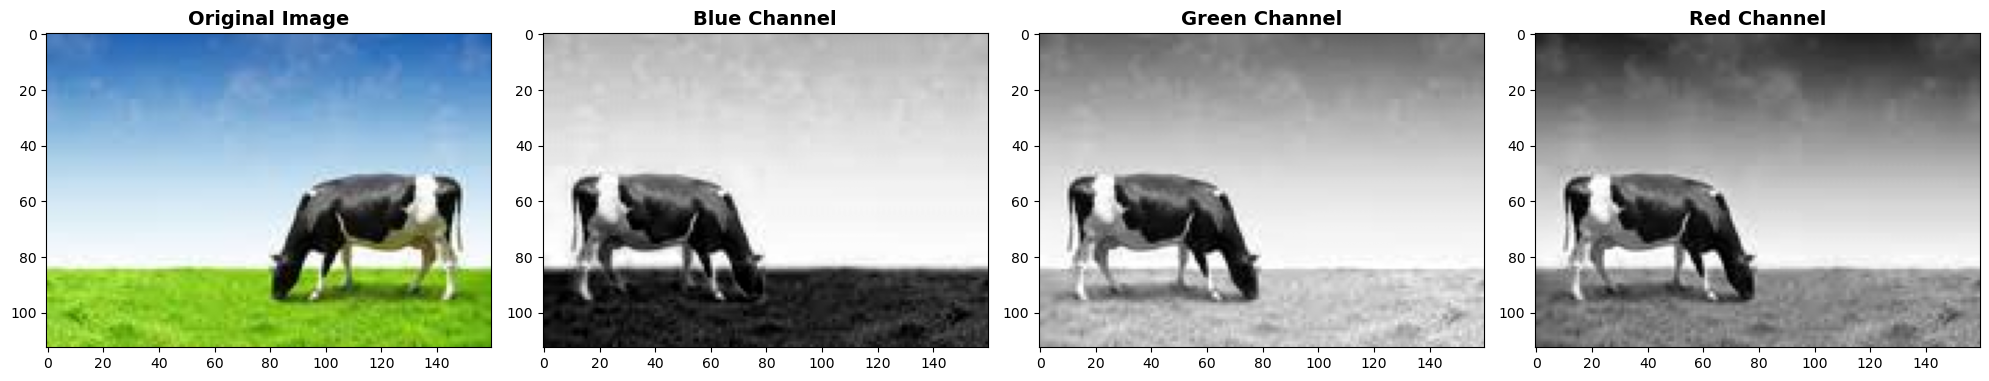

In [7]:
fig, axes = plt.subplots(figsize=(20, 5), nrows=1, ncols=4)

channels = [image, blue, green, red]
titles = ["Original Image", "Blue Channel", "Green Channel", "Red Channel"]

for i , (channel, title) in enumerate(zip(channels, titles)):
    axes[i].imshow(channel[..., ::-1], cmap="gray")
    axes[i].set_title(title, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

By visualizing the channels of the cow image separately, you can conclude that red channel has a general low intensity in the image, and the upper part of the image is rich in blue, and the bottom part is rich in green without seeing the original image.

## **9. Merging Channels**

After processing individual channels, they can be combined to reconstruct a color image.

OpenCV provides the `cv2.merge()` function for this purpose.

### **Syntax**

```python
merged = cv2.merge((blue, green, red))
```

The order of the channels is important.

Since OpenCV uses the BGR color space, the channels must be merged as:

- Blue
- Green
- Red

If the order is changed, the resulting image will display incorrect colors.

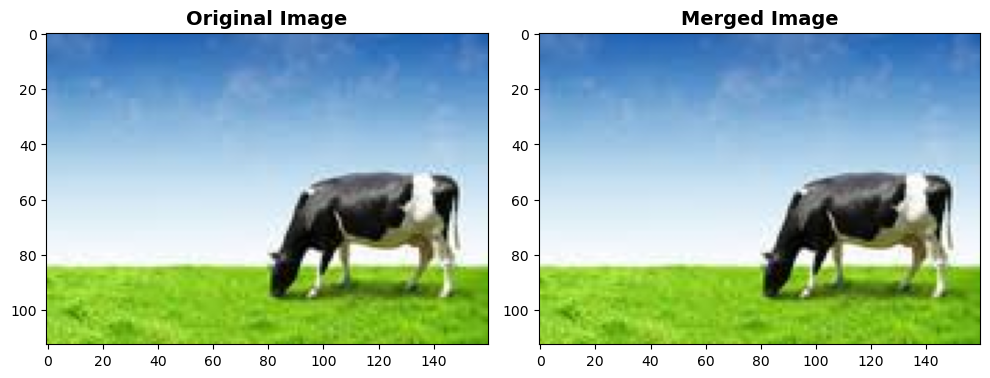

In [11]:
merged_image = cv2.merge([blue, green, red])

fig, axes = plt.subplots(figsize=(10, 5), nrows=1, ncols=2)

axes[0].imshow(image[..., ::-1])
axes[0].set_title("Original Image", fontsize=14, fontweight="bold")

axes[1].imshow(merged_image[..., ::-1])
axes[1].set_title("Merged Image", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In the previous example, we split the image into its Blue, Green, and Red channels and then merged them back together without making any modifications. As expected, the reconstructed image is identical to the original because the pixel values remained unchanged.

Now, let's explore the true power of channel manipulation. By modifying one or more channels before merging them, we can dramatically change the appearance of the image. This experiment will help us understand the contribution of each color channel and build an intuition for how OpenCV represents color images.

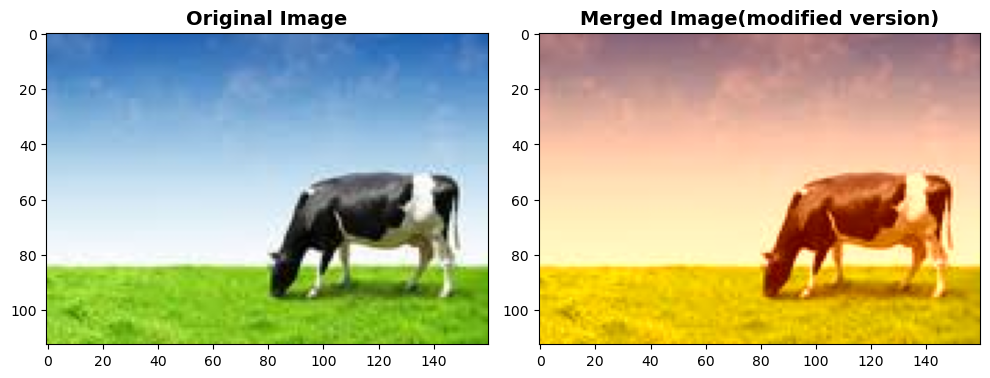

In [13]:
new_red = cv2.add(red, 100)
new_blue = cv2.subtract(blue, 60)

merged_image_modified = cv2.merge([new_blue, green, new_red])

fig, axes = plt.subplots(figsize=(10, 5), nrows=1, ncols=2)

axes[0].imshow(image[..., ::-1])
axes[0].set_title("Original Image", fontsize=14, fontweight="bold")

axes[1].imshow(merged_image_modified[..., ::-1])
axes[1].set_title("Merged Image(modified version)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


In the resulting image, the intensity of the **Red** channel has been increased, while the intensity of the **Blue** channel has been reduced before the channels were merged. As a result, the reconstructed image exhibits warmer tones and noticeably different colors compared to the original.

To modify the channel intensities, we used the `cv2.add()` and `cv2.subtract()` functions. These functions provide a safe and efficient way to adjust pixel values while preventing overflow and underflow. Although we use them here to demonstrate channel manipulation, they are general-purpose image processing functions that will be covered in detail in a future notebook.

## **10. Why Merge Channels?**

Splitting channels is only useful if we can later reconstruct the image.

After enhancing, filtering, or modifying one or more channels, the processed channels are merged together to produce a new color image.

This technique is widely used in:

- Color correction
- Contrast enhancement
- Image restoration
- Medical image analysis
- Satellite imagery
- Object detection

## **11. Common Mistakes**

When working with image channels, beginners often encounter the following mistakes:

- Assuming each channel is still a color image. In reality, each channel is a single-channel grayscale image.
- Forgetting that OpenCV stores images in **BGR** order rather than **RGB**.
- Merging channels in the wrong order, producing unrealistic colors.
- Attempting to merge channels of different sizes, which results in an error because all channels must have identical dimensions.

## **12. Best Practices**

- Always verify the shape of each channel after splitting.
- Remember that `cv2.split()` returns grayscale images.
- Keep the original channel order unless intentionally creating a visual effect.
- Avoid unnecessary splitting if your algorithm does not require channel-specific processing, as splitting and merging large images introduces additional computational overhead.

## **13. Summary**

In this notebook, you learned that a color image is composed of three independent channels representing the Blue, Green, and Red components of every pixel.

You learned how to separate these channels using `cv2.split()`, inspect them individually, and reconstruct the original image using `cv2.merge()`.

Understanding image channels is an important milestone in computer vision because many image processing algorithms operate on individual channels rather than the complete color image. Mastering channel manipulation prepares you for more advanced topics such as masking, color segmentation, histogram equalization, and feature extraction.

## **14. Practice Exercises**

1. Split a color image into its Blue, Green, and Red channels.
2. Display each channel individually and describe which objects appear brightest in each one.
3. Print the shape of the original image and each channel. Explain why they differ.
4. Merge the channels back together and verify that the reconstructed image matches the original.
5. Swap the Blue and Red channels before merging. Describe how the colors change.
6. Set the Green channel to zero before merging. Predict the appearance of the resulting image before executing the code, then verify your prediction.

## **Experiment: Create Your Own Color Filters**

Try modifying one channel before merging the image again.

- Set one channel to zero.
- Increase one channel's brightness.
- Swap the Red and Blue channels.
- Duplicate the Green channel into all three channels.

Before running each experiment, predict what the image will look like. Then compare your prediction with the actual result.

The goal is not only to learn the functions, but also to develop an intuition for how color images are represented and manipulated by a computer.